# Production model status

Read-only. Shows the **current promoted model's** stored metrics and
per-session predictions from `models_registry`/`predictions` — no
retraining, no CV refit. For a periodic "is the production model still
good" check where a full re-run (`stacked_ensemble_review.ipynb`, several
minutes) isn't needed.

`predictions` rows are written once at promotion time
(`bagpipe.models.promote`) and are only as fresh as the last `bag models
promote` run — if a newer model was trained but not promoted, this won't
show it. No subject IDs printed below, aggregate only.

In [1]:
import json
import os
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats

from bagpipe.core.config import get_path

# repo root, regardless of the kernel's actual cwd — outputs/datasets_v26 is
# referenced by a repo-relative path in §2 below.
_root = Path.cwd()
while not (_root / "pyproject.toml").exists():
    _root = _root.parent
os.chdir(_root)

sns.set_theme(style="whitegrid")
con = sqlite3.connect(get_path("db_path"))

## 1. Production model row

In [2]:
model = pd.read_sql(
    "select * from models_registry where stage='production' order by trained_at desc limit 1", con
).iloc[0]
model_id = int(model["model_id"])
metrics = json.loads(model["metrics_json"])
config = json.loads(model["config_json"])

print(f"model_id={model_id}  {model['name']} {model['version']}  trained_at={model['trained_at']}")
print("stored CV metrics:", metrics)
print("config:", config)

model_id=31  stacked v26-20260903  trained_at=2026-09-03 02:16:22
stored CV metrics: {'mae_raw': 4.845700945646498, 'mae_corrected': 5.747539312329698, 'r2_raw': 0.6944133342296759, 'r2_corrected': 0.5498048298636167}
config: {'datasets_dir': 'outputs/datasets_v26', 'features': {'metrics': ['vol_gm', 'vol_wm', 'vol_csf']}, 'stacker': {'base_estimator': {'type': 'ridgecv_interactions'}, 'meta_estimator': {'type': 'ridgecv'}, 'outer_cv': 5, 'inner_cv': 3, 'n_jobs': -1, 'random_state': 0}, 'bias_correction': 'cole', 'n_splits': 5, 'mlflow': {'experiment': 'bagpipe-cat12v26', 'run_name': 'stacked-ridgecvinteractions-ridgecv-cole-v26'}}


## 2. Per-session predictions (already stored — no refit)

In [3]:
pred = pd.read_sql(f"select * from predictions where model_id = {model_id}", con)

# Sex from the same globals.parquet export used at training time — not a raw
# `demographics` join, which only covers the SNBB cohort (legacy-cohort sex
# lives in `legacy_participant.gender`, keyed by subject_key not session_id).
datasets_dir = Path(config["datasets_dir"]) if config.get("datasets_dir") else get_path("datasets_dir")
sex = pd.read_parquet(datasets_dir / "globals.parquet")[["subject_key", "session_id", "sex"]]
pred = pred.merge(sex, on=["subject_key", "session_id"], how="left")
print(f"{len(pred)} stored predictions, {pred['sex'].notna().sum()} with known sex")
pred.drop(columns=["subject_key", "session_id"]).describe()

2260 stored predictions, 2260 with known sex


,id,model_id,fold,age_true,predicted_age_raw,predicted_age_corrected,bag_raw,bag_corrected
count,2260.000000,2260.0,2260.000000,2260.000000,2260.000000,2260.000000,2260.000000,2260.000000
mean,29821.500000,31.0,2.000000,32.687444,32.849969,32.681354,0.162524,-0.006090
std,652.550126,0.0,1.414527,11.697880,10.001584,14.216077,6.464532,7.848875
min,28692.000000,31.0,0.000000,9.234771,-13.918483,-33.340711,-44.018483,-63.440711
25%,29256.750000,31.0,1.000000,24.980000,26.660454,23.890505,-3.213992,-4.883833
50%,29821.500000,31.0,2.000000,28.729134,30.711313,29.641942,0.613549,-0.396576
75%,30386.250000,31.0,3.000000,36.187500,36.192776,37.421445,4.152939,4.164909
max,30951.000000,31.0,4.000000,84.690000,93.847631,118.964947,32.180930,50.264161


## 3. Sanity check — recomputed MAE/R² from stored predictions vs. `metrics_json`

Should match the registry row (both come from the same CV run); a mismatch
would mean `predictions` is stale relative to `models_registry` (e.g.
promoted again without re-persisting predictions).

In [4]:
from sklearn.metrics import mean_absolute_error, r2_score

recomputed = {
    "mae_raw": mean_absolute_error(pred["age_true"], pred["predicted_age_raw"]),
    "mae_corrected": mean_absolute_error(pred["age_true"], pred["predicted_age_corrected"]),
    "r2_raw": r2_score(pred["age_true"], pred["predicted_age_raw"]),
    "r2_corrected": r2_score(pred["age_true"], pred["predicted_age_corrected"]),
}
pd.DataFrame({"stored (metrics_json)": metrics, "recomputed (predictions table)": recomputed})

,stored (metrics_json),recomputed (predictions table)
mae_raw,4.845701,4.845701
mae_corrected,5.747539,5.747539
r2_raw,0.694413,0.694413
r2_corrected,0.549805,0.549805


## 4. Diagnostics

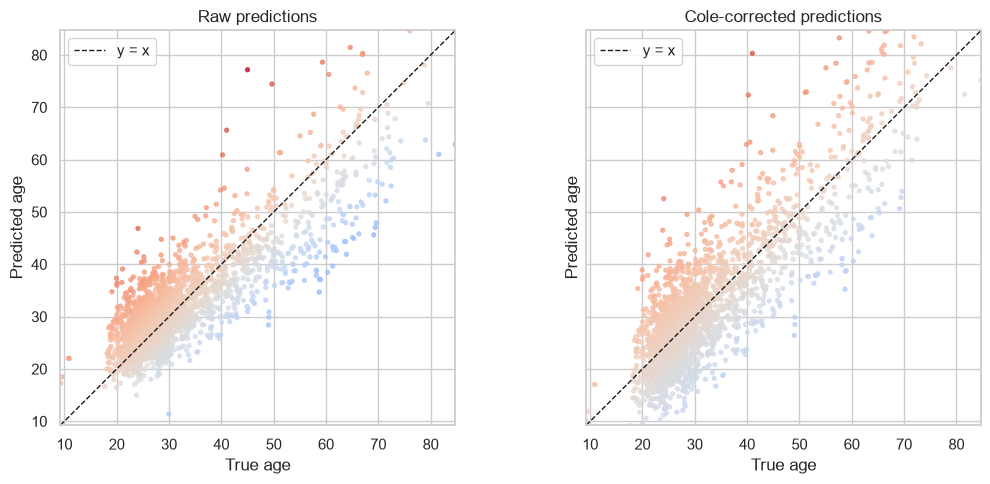

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharex=True, sharey=True)
for ax, col, title in zip(axes, ["predicted_age_raw", "predicted_age_corrected"], ["Raw", "Cole-corrected"]):
    # color the points by their distance from the y=x line, to highlight the bias in the raw predictions
    dist = pred[col] - pred["age_true"]
    cmap = sns.color_palette("coolwarm", as_cmap=True)
    sc = ax.scatter(pred["age_true"], pred[col], c=dist, cmap=cmap, s=8, alpha=0.7)
    lims = [pred["age_true"].min(), pred["age_true"].max()]
    ax.plot(lims, lims, "k--", lw=1, label="y = x")
    ax.set_xlabel("True age")
    ax.set_ylabel("Predicted age")
    ax.set_title(f"{title} predictions")
    ax.legend()
# make y and x axes equal, and add a colorbar for the distance-from-y=x coloring
for ax in axes:
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(lims)
    ax.set_ylim(lims)
plt.tight_layout()

In [6]:
# find the 10 most extreme corrected absolute BAG values, to see if they are plausible
pred.sort_values("bag_corrected", ascending=False, key=abs)
# pred.sort_values("session_id", ascending=False).head(20)
# pred[pred["subject_key"].str.startswith("S")]

,id,model_id,subject_key,session_id,fold,age_true,predicted_age_raw,predicted_age_corrected,bag_raw,bag_corrected,created_at,sex
932,29624,31,200902060834,200902060834,2,30.100000,-13.918483,-33.340711,-44.018483,-63.440711,2026-09-03 02:16:24,Male
7,28699,31,200707270944,200707270944,0,45.000000,77.180930,95.264161,32.180930,50.264161,2026-09-03 02:16:22,Female
1025,29717,31,201603070809,201603070809,2,69.410000,91.008042,114.951761,21.598042,45.541761,2026-09-03 02:16:24,Male
943,29635,31,200908281038,200908281038,2,75.710000,93.847631,118.964947,18.137631,43.254947,2026-09-03 02:16:24,Female
1544,30236,31,S020543,202211061614,3,49.670000,74.443003,91.379422,24.773003,41.709422,2026-09-03 02:16:24,Male
...,...,...,...,...,...,...,...,...,...,...,...,...
853,29545,31,S249413,202504270944,1,46.091718,42.064995,46.112561,-4.026723,0.020843,2026-09-03 02:16:24,Male
1639,30331,31,S113829,202503170900,3,40.681725,38.584512,40.667431,-2.097212,-0.014294,2026-09-03 02:16:24,Male
2093,30785,31,S112911,202206131754,4,22.460000,25.650760,22.473294,3.190760,0.013294,2026-09-03 02:16:24,Female
383,29075,31,S218386,202211201402,0,23.630000,26.456743,23.642448,2.826743,0.012448,2026-09-03 02:16:23,Male


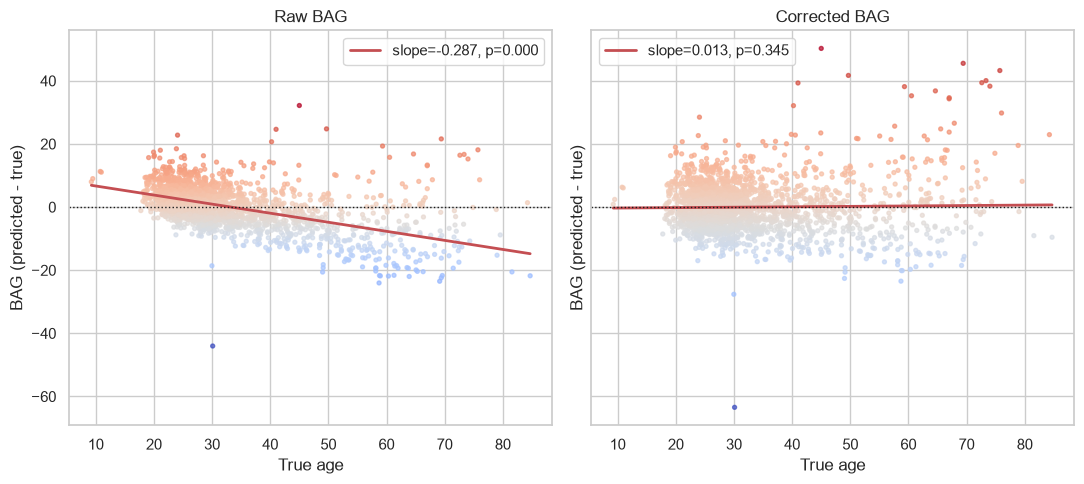

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharex=True, sharey=True)
for ax, col, title in zip(axes, ["bag_raw", "bag_corrected"], ["Raw BAG", "Corrected BAG"]):
    # color the points by their distance from the y=x line, to highlight the bias in the raw predictions
    dist = pred[col]
    cmap = sns.color_palette("coolwarm", as_cmap=True)
    sc = ax.scatter(pred["age_true"], pred[col], c=dist, cmap=cmap, s=8, alpha=0.7)
    # ax.scatter(pred["age_true"], pred[col], s=8, alpha=0.3)
    slope, intercept, r, p, se = stats.linregress(pred["age_true"], pred[col])
    xs = pred["age_true"].agg(["min", "max"]).to_numpy()
    ax.plot(xs, slope * xs + intercept, "r-", lw=2, label=f"slope={slope:.3f}, p={p:.3f}")
    ax.axhline(0, color="k", lw=1, ls=":")
    ax.set_xlabel("True age")
    ax.set_ylabel("BAG (predicted - true)")
    ax.set_title(title)
    ax.legend()
plt.tight_layout()

<Axes: xlabel='bag_corrected', ylabel='Density'>

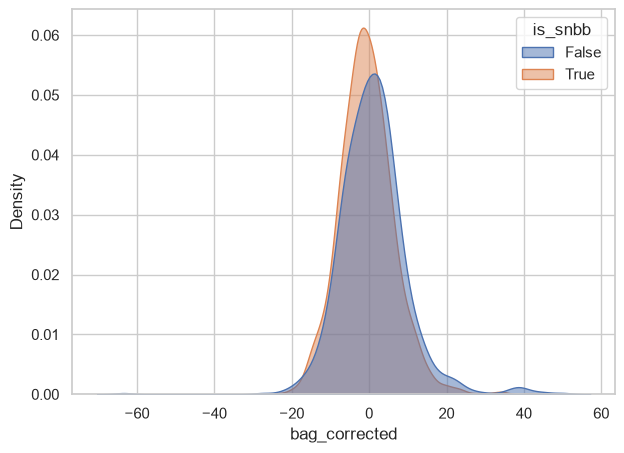

In [8]:
import seaborn as sns
df = pred.copy()
df["is_snbb"] = df["subject_key"].str.startswith("S")
fig, ax = plt.subplots(figsize=(7, 5))
sns.kdeplot(data=df, x="bag_corrected", hue="is_snbb", fill=True, common_norm=False, alpha=0.5, ax=ax)

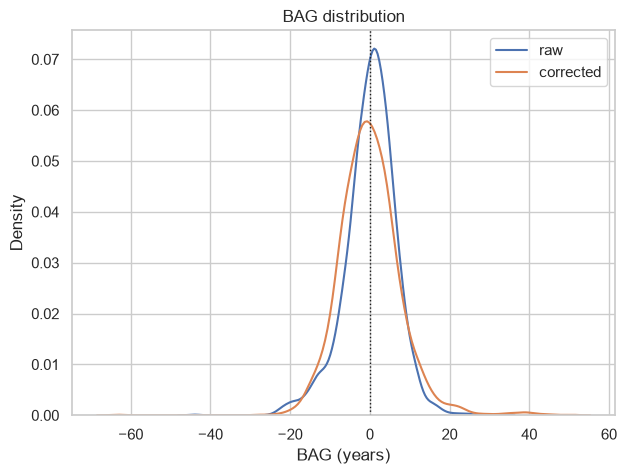

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.kdeplot(pred["bag_raw"], label="raw", ax=ax)
sns.kdeplot(pred["bag_corrected"], label="corrected", ax=ax)
ax.axvline(0, color="k", lw=1, ls=":")
ax.set_xlabel("BAG (years)")
ax.set_title("BAG distribution")
ax.legend()

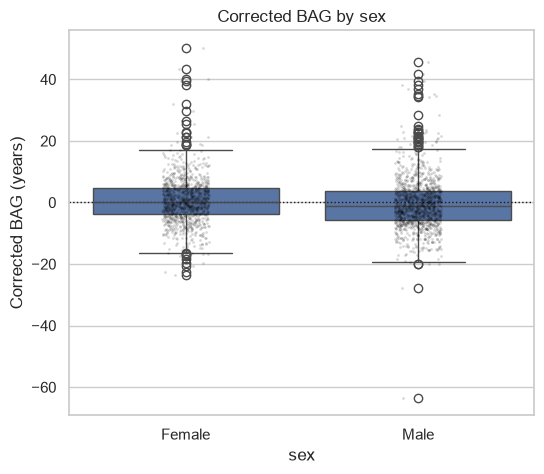

Male:   mean BAG=-0.57y, n=1216
Female: mean BAG=+0.65y, n=1044
Mann-Whitney U p-value: 2.27e-06


In [10]:
sexed = pred.dropna(subset=["sex"])
fig, ax = plt.subplots(figsize=(6, 5))
sns.boxplot(data=sexed, x="sex", y="bag_corrected", ax=ax)
sns.stripplot(data=sexed, x="sex", y="bag_corrected", ax=ax, color="black", alpha=0.15, size=2)
ax.axhline(0, color="k", lw=1, ls=":")
ax.set_ylabel("Corrected BAG (years)")
ax.set_title("Corrected BAG by sex")
plt.show()

male_bag = sexed.loc[sexed["sex"] == "Male", "bag_corrected"]
female_bag = sexed.loc[sexed["sex"] == "Female", "bag_corrected"]
u_stat, p_value = stats.mannwhitneyu(male_bag, female_bag)
print(f"Male:   mean BAG={male_bag.mean():+.2f}y, n={len(male_bag)}")
print(f"Female: mean BAG={female_bag.mean():+.2f}y, n={len(female_bag)}")
print(f"Mann-Whitney U p-value: {p_value:.3g}")

## 5. Per-fold breakdown

Checks the CV folds weren't lopsided (one fold dragging the average).

In [11]:
pred.groupby("fold").apply(
    lambda d: pd.Series({
        "n": len(d),
        "mae_raw": mean_absolute_error(d["age_true"], d["predicted_age_raw"]),
        "mae_corrected": mean_absolute_error(d["age_true"], d["predicted_age_corrected"]),
    }),
    include_groups=False,
)

,n,mae_raw,mae_corrected
fold,,,
0,452.0,5.287992,5.887857
1,452.0,4.762958,5.541519
2,452.0,4.873492,6.166132
3,452.0,4.544552,5.510205
4,452.0,4.759511,5.631984
